# Linear & Kernel Attention (Toy Study)

**Цель.** Показать идею линейного / kernel attention как приближения обычного softmax-attention и сравнить:
- карты внимания,
- ошибку аппроксимации,
- масштабирование по длине последовательности.

**Важно.** Это toy-эксперимент: не SOTA и не численно стабильная реализация Performer, а проверка идеи.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(0)

## 1. Базовый softmax-attention

In [3]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=axis, keepdims=True)

def softmax_attention(Q, K, V):
    logits = Q @ K.T
    W = softmax(logits, axis=-1)
    return W @ V, W

## 2. Kernel / Linear attention (toy)

In [4]:
def phi(x):
    # Простая положительная feature map (toy)
    return np.maximum(x, 0.0) + 1.0

def kernel_attention(Q, K, V):
    Phi_Q = phi(Q)   # (n, d)
    Phi_K = phi(K)   # (n, d)

    # (d, d)
    KV = Phi_K.T @ V

    # нормировка: Z_i = phi(q_i)^T sum_j phi(k_j)
    # sum_phiK: (d,)
    sum_phiK = Phi_K.sum(axis=0)
    # Z: (n, 1)
    Z = (Phi_Q @ sum_phiK[:, None])

    out = (Phi_Q @ KV) / (Z + 1e-8)
    return out


## 3. Сравнение карт внимания (toy)

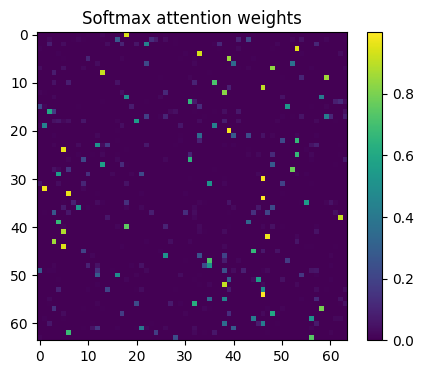

In [5]:
n, d = 64, 32
Q = np.random.randn(n, d)
K = np.random.randn(n, d)
V = np.random.randn(n, d)

_, W_soft = softmax_attention(Q, K, V)

plt.figure(figsize=(5,4))
plt.imshow(W_soft, aspect='auto')
plt.colorbar()
plt.title('Softmax attention weights')
plt.show()

## 4. Масштабирование по длине последовательности

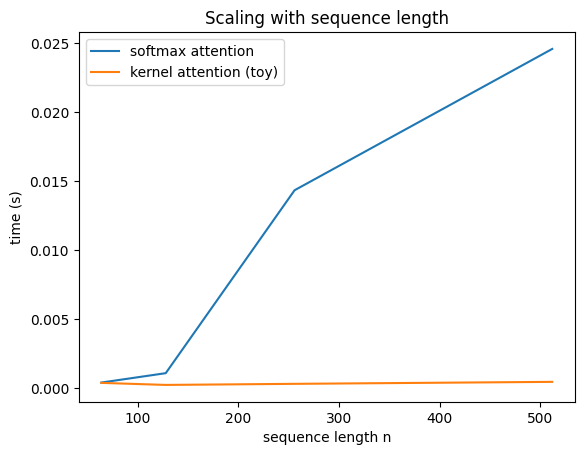

In [6]:
def measure_time(att_fn, n, d=32):
    Q = np.random.randn(n, d)
    K = np.random.randn(n, d)
    V = np.random.randn(n, d)
    t0 = time.perf_counter()
    att_fn(Q, K, V)
    return time.perf_counter() - t0

ns = [64, 128, 256, 512]
t_soft = [measure_time(lambda Q,K,V: softmax_attention(Q,K,V), n) for n in ns]
t_kernel = [measure_time(lambda Q,K,V: kernel_attention(Q,K,V), n) for n in ns]

plt.figure()
plt.plot(ns, t_soft, label='softmax attention')
plt.plot(ns, t_kernel, label='kernel attention (toy)')
plt.xlabel('sequence length n')
plt.ylabel('time (s)')
plt.legend()
plt.title('Scaling with sequence length')
plt.show()

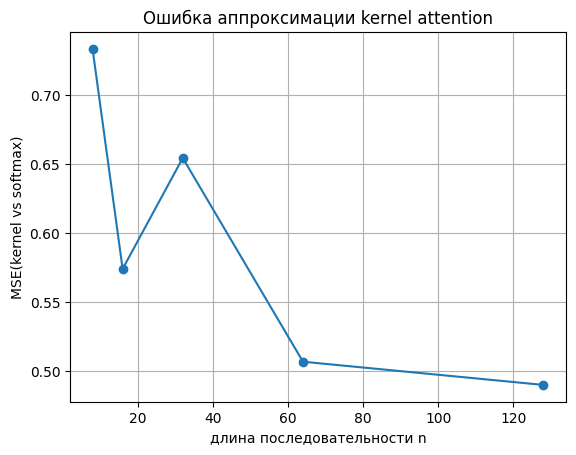

In [7]:
# 4. Ошибка аппроксимации: kernel vs softmax

def attention_mse(Q, K, V):
    out_soft, _ = softmax_attention(Q, K, V)
    out_kernel  = kernel_attention(Q, K, V)
    return np.mean((out_soft - out_kernel) ** 2)

ds = [8, 16, 32, 64, 128]
errors = []

for n in ds:
    d = 32
    Q = np.random.randn(n, d)
    K = np.random.randn(n, d)
    V = np.random.randn(n, d)
    errors.append(attention_mse(Q, K, V))

plt.figure()
plt.plot(ds, errors, marker="o")
plt.xlabel("длина последовательности n")
plt.ylabel("MSE(kernel vs softmax)")
plt.title("Ошибка аппроксимации kernel attention")
plt.grid(True)
plt.show()


## 5. Выводы

- Softmax-attention имеет квадратичную зависимость от длины последовательности.
- Kernel/linear attention устраняет явное `n×n`, выигрывая по времени.
- Цена — аппроксимация и возможная потеря качества.

В реальных моделях (Performer и др.) используются более стабильные feature maps и нормировки.